# k-Nearest Neighbors

Empezamos con una implementación sencilla usando distancia euclídea para determinar los vecinos más cercanos.
La predicción se hace mediante la regla de la mayoría. En caso de empate se reduce el número de vecinos hasta que encontramos un ganador.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def euclidean_distance(x,y):
    return np.linalg.norm(y-x)

In [3]:
def predict_knn(k, X_train, y_train, x_point):
    """
    Predice la etiqueta de un punto de datos `x_point` utilizando el algoritmo K-Nearest Neighbors (KNN).
    
    Parámetros:
    -----------
    k : int
        El número de vecinos más cercanos a considerar para la predicción.
    X_train : np.ndarray o list de listas
        Conjunto de datos de entrenamiento (matriz de características).
    y_train : np.ndarray o list
        Etiquetas correspondientes a los puntos de datos en `X_train`.
    x_point : np.ndarray o list
        El punto de datos para el cual se desea predecir la etiqueta.

    Retorna:
    --------
    label : int o float
        La etiqueta predicha para el punto de datos `x_point` basándose en los `k` vecinos más cercanos.
    """
    k_nearest = k_closest(k, X_train, x_point)
    label = majority_vote(y_train[k_nearest])
    
    return label


def k_closest(k, X, point):
    """
    Encuentra los `k` vecinos más cercanos a un punto de datos `point` en un conjunto de datos `X`.
    
    Parámetros:
    -----------
    k : int
        Número de vecinos más cercanos a seleccionar.
    X : np.ndarray o list de listas
        Conjunto de datos (matriz de características) en el cual se buscarán los vecinos.
    point : np.ndarray o list
        El punto de datos cuyo vecino más cercano se busca.

    Retorna:
    --------
    np.ndarray
        Índices de los `k` puntos más cercanos a `point` en `X`, ordenados por proximidad.
    """
    distances = np.array([euclidean_distance(x, point) for x in X])  
    return np.argsort(distances)[:k]


def majority_vote(Y_k):
    """
    Realiza una votación mayoritaria entre las etiquetas `Y_k` de los `k` vecinos más cercanos.
    
    Si hay un empate, se eliminan elementos de la lista de votos hasta que se obtenga un único ganador.
    
    Parámetros:
    -----------
    Y_k : list o np.ndarray
        Las etiquetas de los `k` vecinos más cercanos.

    Retorna:
    --------
    max_voted : int o float
        La etiqueta que recibe la mayoría de los votos entre los `k` vecinos.
    
    Notas:
    ------
    Este método puede ser ineficiente cuando hay muchos empates, ya que elimina elementos de la lista iterativamente.
    """
    Y_k_copy = list(Y_k.copy())
    num_max_votes = 0
    while num_max_votes != 1:  # Este bucle asegura que haya un único ganador.
        
        y_labels = list(np.unique(Y_k_copy))  # Lista de etiquetas únicas.
        y_votes = [Y_k_copy.count(y) for y in y_labels]  # Número de votos por cada etiqueta.

        max_votes = max(y_votes)  # Número máximo de votos obtenidos.
        max_voted = y_labels[y_votes.index(max_votes)]  # La primera etiqueta más votada.
        num_max_votes = y_votes.count(max_votes)  # Verifica si hay empates.

        Y_k_copy.pop()  # Elimina el último elemento para desempatar si es necesario.
    
    return max_voted


def majority_vote_recursive(Y_k):
    """
    Realiza una votación mayoritaria entre las etiquetas `Y_k` utilizando un enfoque recursivo.
    
    En caso de empate, elimina elementos de la lista de etiquetas y vuelve a llamar a la función recursivamente.
    
    Parámetros:
    -----------
    Y_k : list o np.ndarray
        Las etiquetas de los `k` vecinos más cercanos.

    Retorna:
    --------
    max_voted : int o float
        La etiqueta que recibe la mayoría de los votos entre los `k` vecinos.
    
    Notas:
    ------
    Este método utiliza recursividad para resolver empates, eliminando un elemento de la lista de etiquetas hasta que haya un único ganador.
    """
    Y_k_copy = Y_k.copy()
    y_labels, y_counts = np.unique(Y_k_copy, return_counts=True)
    max_votes = np.max(y_counts)
    num_max_votes = np.sum(y_counts == max_votes)

    if num_max_votes == 1:
        return y_labels[np.argmax(y_counts)]
    else:
        Y_k_copy.pop()  # Elimina el último elemento si hay empate.
        return majority_vote_recursive(Y_k_copy)



## k-NN en Iris dataset.

0.96


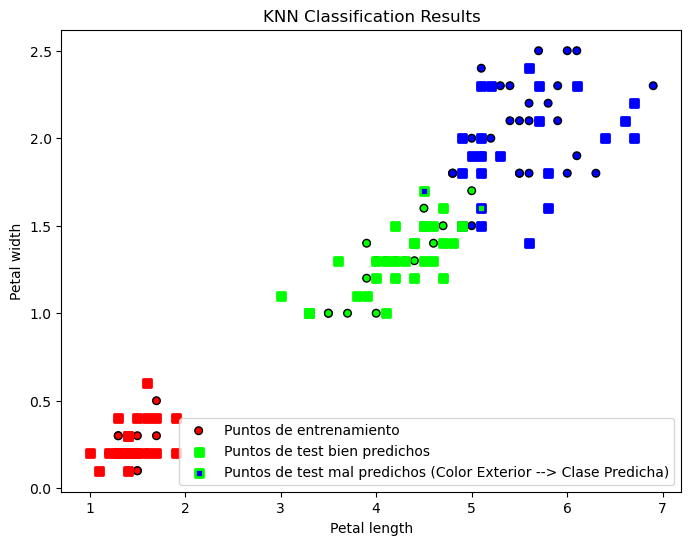

In [4]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=74)

predictions = [predict_knn(1, X_train, y_train,  x_point) for x_point in X_test]
acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

# Plotting
plt.figure(figsize=(8, 6))

# Scatter plot of all the training data (using features petal length and petal width)
plt.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap, edgecolor='k', s=30, label="Puntos de entrenamiento")


# Scatter plot of all the test data with real class colors and predicted class as border color
flag_right = 1
flag_wrong = 1
for i, x_point in enumerate(X_test):
    
    # Color del centro: clase real (ground truth)
    face_col = cmap(y_test[i])
    # Color del borde: clase predicha
    edge_col = cmap(predictions[i])

    # Si coincide, el punto será monocolor
    if (y_test[i]==predictions[i] & flag_right == 1 ):
        plt.scatter(x_point[2], x_point[3], edgecolor=edge_col, facecolor=face_col, marker='s', s=30, linewidth=2, label= "Puntos de test bien predichos")
        flag_right = 0
    if (y_test[i]!=predictions[i] & flag_wrong == 1 ):
        plt.scatter(x_point[2], x_point[3], edgecolor=edge_col, facecolor=face_col, marker='s', s=30, linewidth=2, label= "Puntos de test mal predichos (Color Exterior --> Clase Predicha)")
        flag_wrong = 0
    else:
        plt.scatter(x_point[2], x_point[3], edgecolor=edge_col, facecolor=face_col, marker='s', s=30, linewidth=2)

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('KNN Classification Results')
plt.legend()
plt.show()

Para evaluar el número idóneo de vecinos hago un barrido por número de vecinos midiendo la precisión.

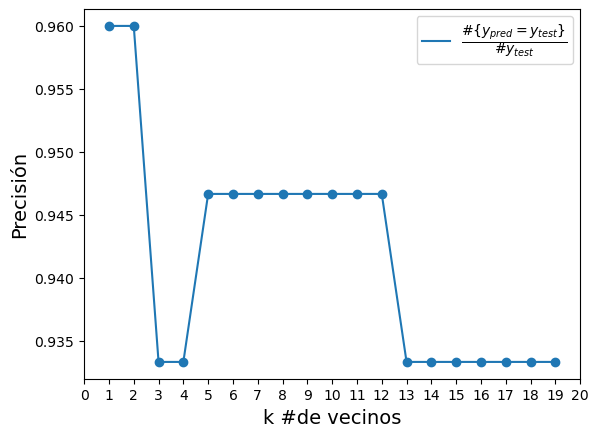

In [5]:
acc = []
for k_value in range(1,20):
    predictions = [predict_knn(k_value, X_train, y_train,  x_point) for x_point in X_test]
    acc.append(np.sum(predictions == y_test) / len(y_test))


    
plt.figure()
plt.plot(range(1,20), acc,  label= r'$\dfrac{\# \{ y_{pred} = y_{test} \} }{\# y_{test}}$')
plt.scatter(range(1,20), acc)
plt.xlabel("k #de vecinos", fontsize=14)
plt.ylabel("Precisión", fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
plt.show()

## Curse of dimensionality

Evalúo como cambia la distancia mínima en media al situar en un espacio d-dimensional 100 puntos de forma aleatoria. Mido la distancia mínima para cada punto y de ahí extraigo la distancia mínima media y el valor mínimo entre esas distancias. 
El número de dimensiones varia desde 1 a 100 de modo que puedo representar como la dimensión afecta a las distancias mínimas.

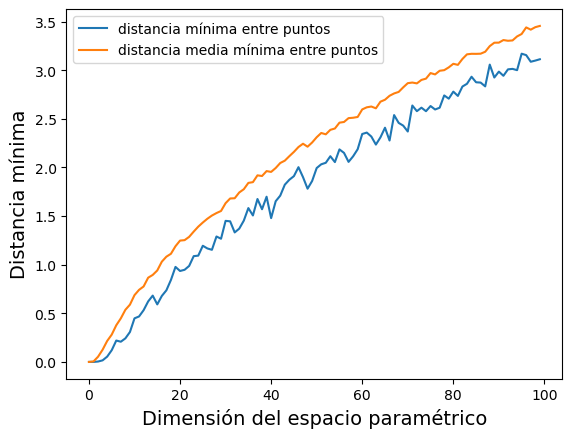

In [6]:
min_distance_dimension = []
avg_distance_dimension = []
for dimension in range(100):
    X = np.random.rand(100,dimension)
    min_distance = []
    for j,point in enumerate(X):
        distancias = [euclidean_distance(x,point) for i,x in enumerate(X) if j!= i]
        min_distance.append(min(distancias))
    min_distance_dimension.append(min(min_distance))   
    avg_distance_dimension.append(np.mean(min_distance))
    
plt.figure()
plt.plot(range(100), min_distance_dimension, label= "distancia mínima entre puntos")
plt.plot(range(100), avg_distance_dimension, label= "distancia media mínima entre puntos")
plt.xlabel("Dimensión del espacio paramétrico", fontsize=14)
plt.ylabel("Distancia mínima", fontsize=14)
plt.legend(loc="upper left", fontsize=10)
plt.show()

## k-NN para Regresión.

Modifico el algoritmo para aplicarlo a problemas de regresión. 
La predicción en este caso va a ser la media ponderada de los valores que toma cada vecino. El peso por el que multiplico el valor del vecino es la inversa de la distancia.

$$
\hat{y_i} = \dfrac{\sum_{j=1}^{k} \frac{1}{d_{ij}}y_j}{\sum_{j=1}^{k} \frac{1}{d_{ij}}}
$$

siendo $d_{ij}$ la distancia entre el punto de test a evaluar $x_i$ y su vecino $x_j$ en el conjunto de entrenamiento.

Ahora la función que determina los índices de los vecinos dentro del conjunto de datos de *train* también devuelve la distancia a la que está del punto de test. Esos valores se pasan a la función *average_weighted* que determina la predicción a devolver. 

In [7]:
def predict_knn_regression(k, X_train, y_train,  x_point):
    
    k_nearest, distances = k_closest_distances(k, X_train, x_point)
    
    label = average_weighted(y_train[k_nearest], distances)
    
    return label

def k_closest_distances(k,X,point):
    
    distances = np.array([euclidean_distance(x,point) for x in X])
    return np.argsort(distances)[:k], np.sort(distances)[:k]


def average_weighted_np(Y_k, weights):
    weights_inverse = 1 / np.array(weights)
    weighted_sum = np.sum(weights_inverse * np.array(Y_k))
    total_weight = np.sum(weights_inverse)
    return weighted_sum / total_weight
    

def average_weighted(Y_k, weights):
    
    sum_value = 0.
    sum_peso = 0.
    for peso,valor in zip(weights,Y_k):
        sum_value += (1/peso)*valor
        sum_peso += (1/peso)
        
    return sum_value/sum_peso


Para evaluarla genero 100 valores de la función $y(x) = \sin(2\pi x) + \Epsilon$ con $x \in [0,1]$ siendo $\Epsilon$ ruido del orden de $10^{-1}$. 
Pretendemos aplicar el algoritmo k-NN para evaluar el valor de 10 puntos equiespaciados en el intervalo $[0,1]$ a partir del valor de sus vecinos.

Text(0, 0.5, 'y')

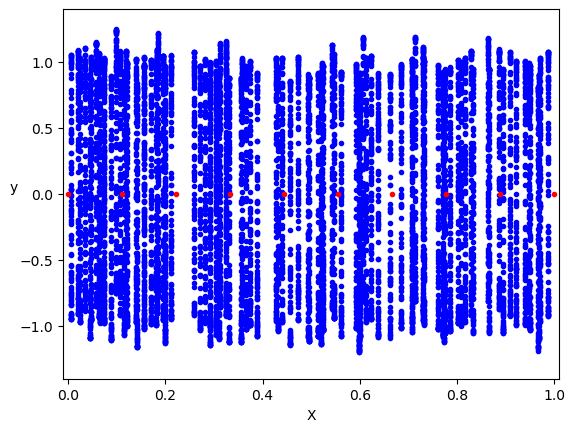

In [ ]:
import numpy as np
np.random.seed(42)
m = 100
X_train = np.random.rand(m,1)
y_train = np.sin(2*np.pi*X_train)
y_train = y_train + np.random.randn(m,1) / 10

X_test = np.linspace(0,1,10)
y_0 = np.zeros_like(X_test)
plt.plot(X_train, y_train, "b.")
plt.plot(X_test, y_0, "r.")

plt.xlim(-0.01,1.01)
plt.ylim(-1.4,1.4)
plt.xlabel("X", fontsize=10)
plt.ylabel("y", fontsize=10, rotation= 0)

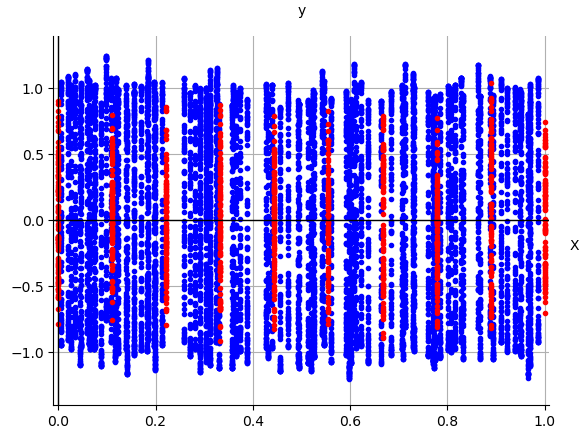

In [9]:
predictions = [predict_knn_regression(5, X_train, y_train,  x_point) for x_point in X_test]


plt.plot(X_train, y_train, "b.")
plt.plot(X_test, predictions, "r.")
plt.xlim(-0.01,1.01)
plt.ylim(-1.4,1.4)
plt.xlabel("X", fontsize=10)
plt.ylabel("y", fontsize=10, rotation= 0)
# Draw the x-axis and y-axis lines at the origin
plt.axhline(y=0, color='black', linewidth=1)
plt.axvline(x=0, color='black', linewidth=1)

# Set the ticks to be at the bottom and left sides
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

# Move the x and y axis labels to be aligned with the axes
plt.gca().xaxis.set_label_coords(1.05, 0.45)
plt.gca().yaxis.set_label_coords(0.5, 1.05)

# Hide the right and top spines
plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')

# Show grid for better visualization
plt.grid(True, which='both')

Una vez calculada los valores originales y la predicción que hace el algoritmo k-NN con k = 5 vamos a representar para cada punto de test los 5 vecinos que han determinado su valor.

ValueError: x and y must have same first dimension, but have shapes (1,) and (99,)

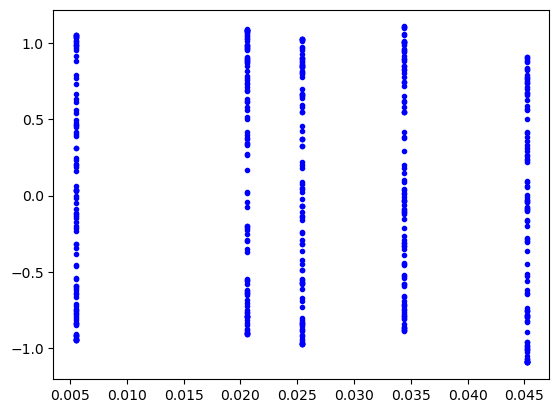

In [10]:
for x_point in X_test:
    k_nearest, distances = k_closest_distances(5, X_train, x_point)
    plt.plot(X_train[k_nearest], y_train[k_nearest], "b.")
    
    label = average_weighted(y_train[k_nearest], distances)
    plt.plot(x_point, label, "r.")
    
plt.xlim(-0.01,1.01)
plt.ylim(-1.4,1.4)
plt.xlabel("X", fontsize=10)
plt.ylabel("y", fontsize=10, rotation= 0)
# Draw the x-axis and y-axis lines at the origin
plt.axhline(y=0, color='black', linewidth=1)
plt.axvline(x=0, color='black', linewidth=1)

# Set the ticks to be at the bottom and left sides
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

# Move the x and y axis labels to be aligned with the axes
plt.gca().xaxis.set_label_coords(1.05, 0.45)
plt.gca().yaxis.set_label_coords(0.5, 1.05)

# Hide the right and top spines
plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')

# Show grid for better visualization
plt.grid(True, which='both')